# Real Time analysis or Stock market Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [11]:
df = pd.read_csv('Pepsico_stock.csv',parse_dates=["Date"])
df

,Date,Close,High,Low,Open,Volume
0,1985-07-01,1.253391,1.261241,1.250774,1.256007,3735000
1,1985-07-02,1.250774,1.261241,1.250774,1.253391,4046400
2,1985-07-03,1.256007,1.258624,1.256007,1.256007,2550600
3,1985-07-05,1.266475,1.266475,1.245542,1.245542,2237400
4,1985-07-08,1.245540,1.266473,1.242923,1.266473,3744000
...,...,...,...,...,...,...
10084,2025-07-11,135.259995,135.389999,133.809998,134.839996,7963600
10085,2025-07-14,135.570007,135.880005,133.860001,134.750000,8480300
10086,2025-07-15,133.809998,135.509995,133.750000,135.429993,8933500
10087,2025-07-16,135.350006,135.509995,133.750000,133.949997,10941600


In [12]:
df.set_index("Date", inplace=True)
df = df[df.index.notna()]
df = df.asfreq("D").fillna(method="ffill")
ts = df["Close"]
ts.head()

C:\Users\deppa\AppData\Local\Temp\ipykernel_27208\248025647.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.asfreq("D").fillna(method="ffill")


Date
1985-07-01    1.253391
1985-07-02    1.250774
1985-07-03    1.256007
1985-07-04    1.256007
1985-07-05    1.266475
Freq: D, Name: Close, dtype: float64

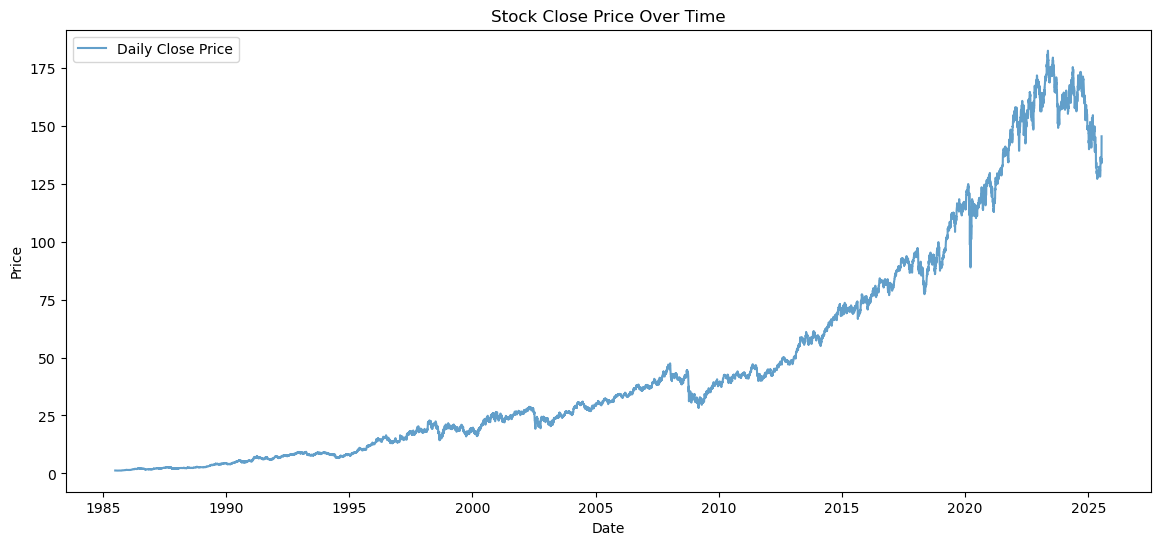

In [13]:
#  Plot the time series
plt.figure(figsize=(14,6))
plt.plot(ts, label="Daily Close Price", alpha=0.7)
plt.title("Stock Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [15]:
# S Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts.dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# Differencing for stationarity
ts_diff = ts.diff().dropna()
adf_result_diff = adfuller(ts_diff)
print(f"\nADF p-value after differencing: {adf_result_diff[1]}")


ADF Statistic: 0.4212916384820812
p-value: 0.9822739458666389

ADF p-value after differencing: 0.0


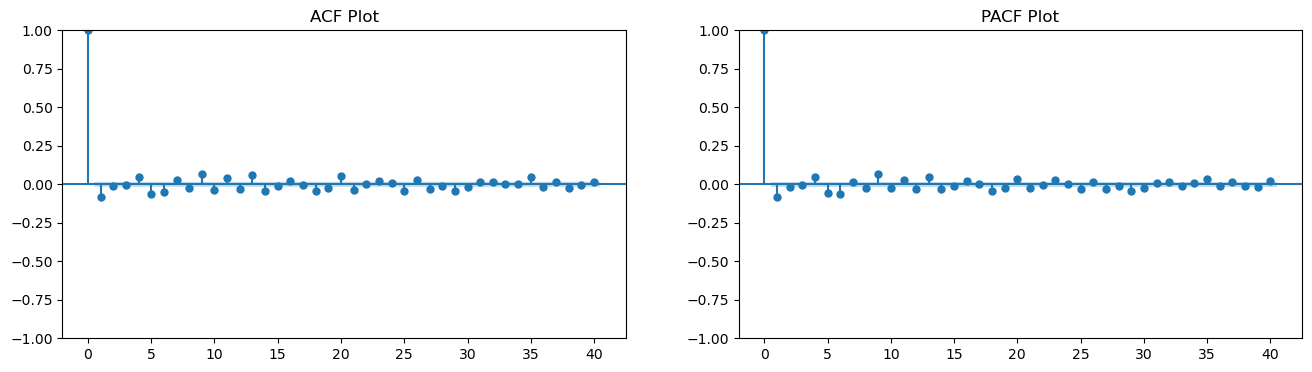

In [16]:
#  ACF and PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16,4))
plot_acf(ts_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF Plot")
plot_pacf(ts_diff, lags=40, ax=axes[1])
axes[1].set_title("PACF Plot")
plt.show()


In [17]:
# Fit ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# Model (p=5, d=1, q=2) — you can tune based on ACF/PACF
model = ARIMA(ts, order=(5,1,2))
model_fit = model.fit()

# Summary
print(model_fit.summary())


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                14627
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -14621.204
Date:                Fri, 25 Jul 2025   AIC                          29258.409
Time:                        13:39:44   BIC                          29319.133
Sample:                    07-01-1985   HQIC                         29278.581
                         - 07-17-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5644      0.025     22.364      0.000       0.515       0.614
ar.L2         -0.3598      0.027    -13.314      0.000      -0.413      -0.307
ar.L3         -0.0246      0.004     -6.745      0.0

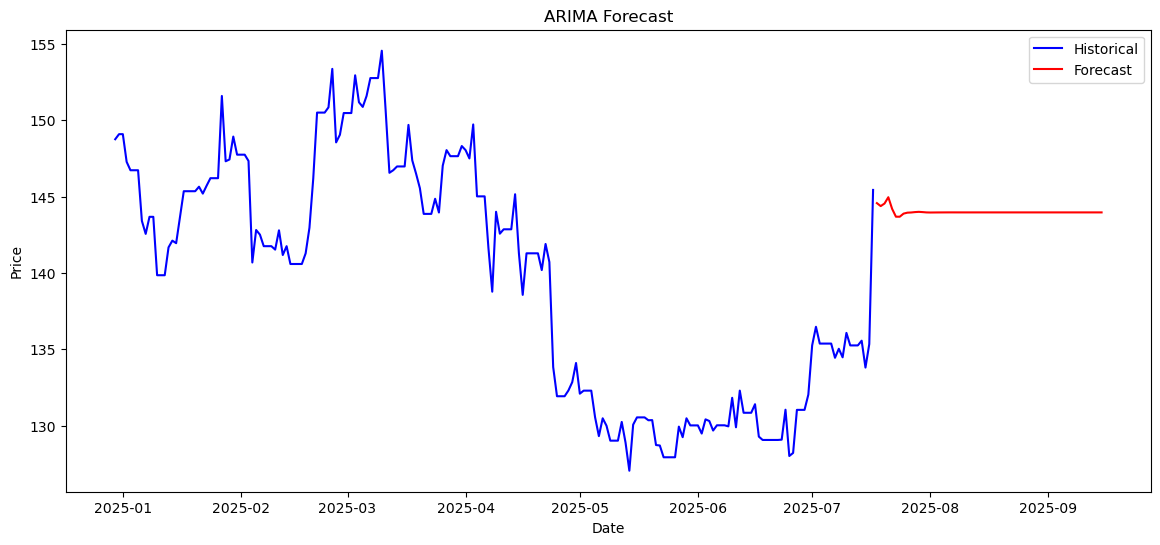

In [18]:
#  Forecast next 60 days
forecast_steps = 60
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the forecast
plt.figure(figsize=(14,6))
plt.plot(ts[-200:], label="Historical", color='blue')
plt.plot(pd.date_range(start=ts.index[-1], periods=forecast_steps+1, freq="D")[1:], forecast, 
         label="Forecast", color="red")
plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [20]:
# Future prediction as DataFrame
future_dates = pd.date_range(start=ts.index[-1], periods=61, freq="D")[1:]
forecast_df = pd.DataFrame({"Date": future_dates, "Forecasted_Close": forecast})

# Save to CSV
forecast_df.to_csv("forecasted_close.csv", index=False)
forecast_df.head()


,Date,Forecasted_Close
2025-07-18,2025-07-18,144.575851
2025-07-19,2025-07-19,144.381501
2025-07-20,2025-07-20,144.548786
2025-07-21,2025-07-21,144.962789
2025-07-22,2025-07-22,144.200395


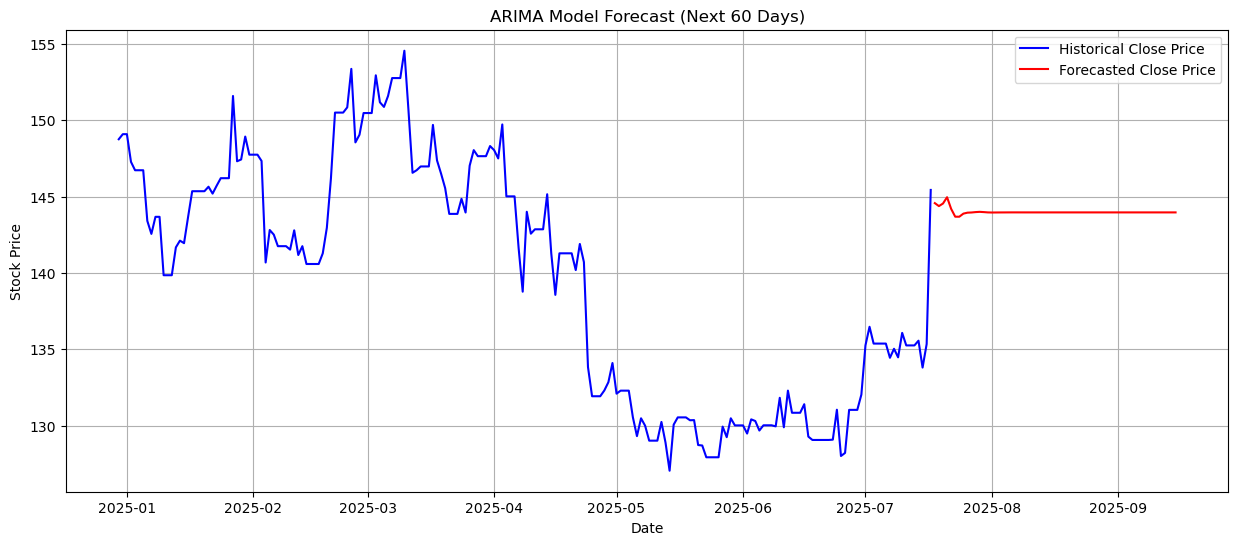

,Date,Forecasted_Close
2025-07-18,2025-07-18,144.575851
2025-07-19,2025-07-19,144.381501
2025-07-20,2025-07-20,144.548786
2025-07-21,2025-07-21,144.962789
2025-07-22,2025-07-22,144.200395
2025-07-23,2025-07-23,143.687817
2025-07-24,2025-07-24,143.686181
2025-07-25,2025-07-25,143.888428
2025-07-26,2025-07-26,143.950748
2025-07-27,2025-07-27,143.963254


In [21]:
plt.figure(figsize=(15,6))
plt.plot(ts[-200:], label="Historical Close Price", color='blue')
plt.plot(forecast_df.index, forecast_df["Forecasted_Close"], label="Forecasted Close Price", color='red')
plt.title("ARIMA Model Forecast (Next 60 Days)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

# Show forecast values
forecast_df.head(10)

# Residing the arima model

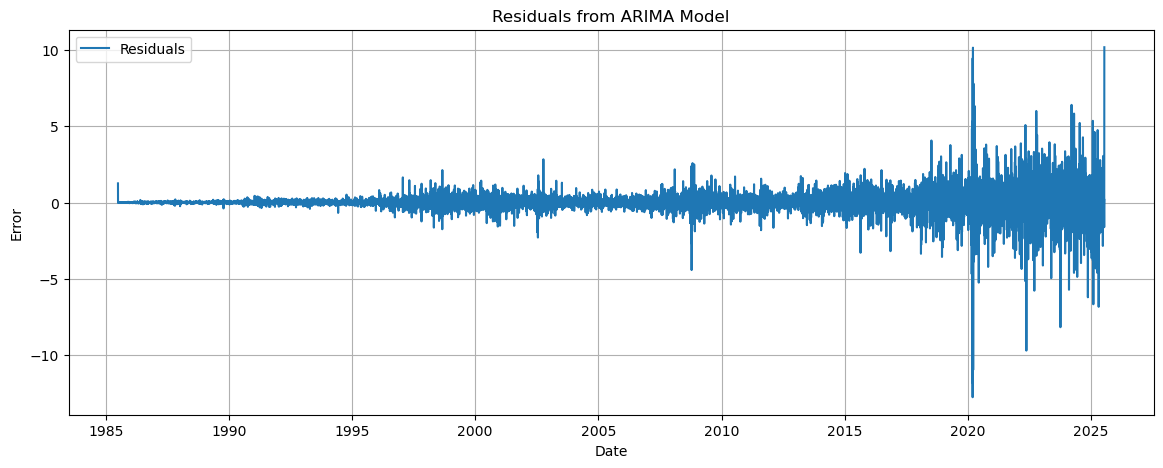

In [23]:
# Step 9: Residual plot
residuals = model_fit.resid

plt.figure(figsize=(14,5))
plt.plot(residuals, label="Residuals")
plt.title("Residuals from ARIMA Model")
plt.xlabel("Date")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()


# checking error form normal or not

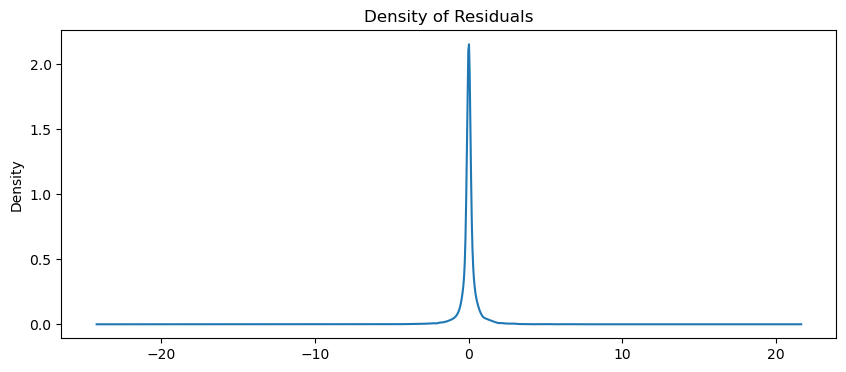

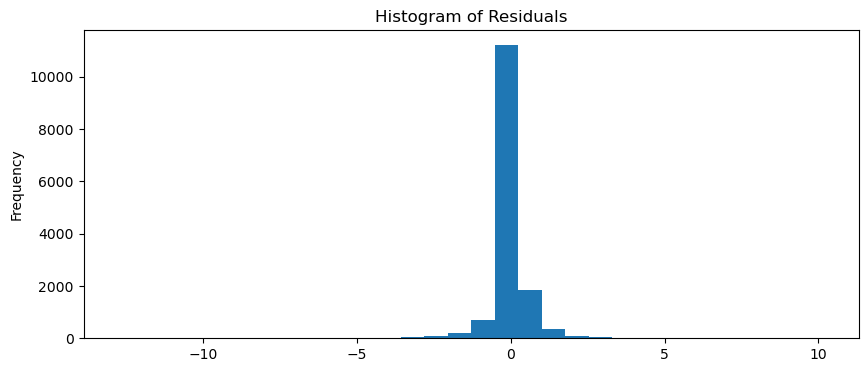

In [25]:
#  Histogram and KDE
residuals.plot(kind='kde', figsize=(10,4), title='Density of Residuals')
plt.show()

residuals.plot(kind='hist', bins=30, figsize=(10,4), title='Histogram of Residuals')
plt.show()


In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Get predicted in-sample values (for last N days)
predicted = model_fit.predict(start=ts.index[-100], end=ts.index[-1])
true = ts[-100:]

mae = mean_absolute_error(true, predicted)
rmse = np.sqrt(mean_squared_error(true, predicted))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)


Mean Absolute Error: 1.0302009692305139
Root Mean Squared Error: 1.776673529539537


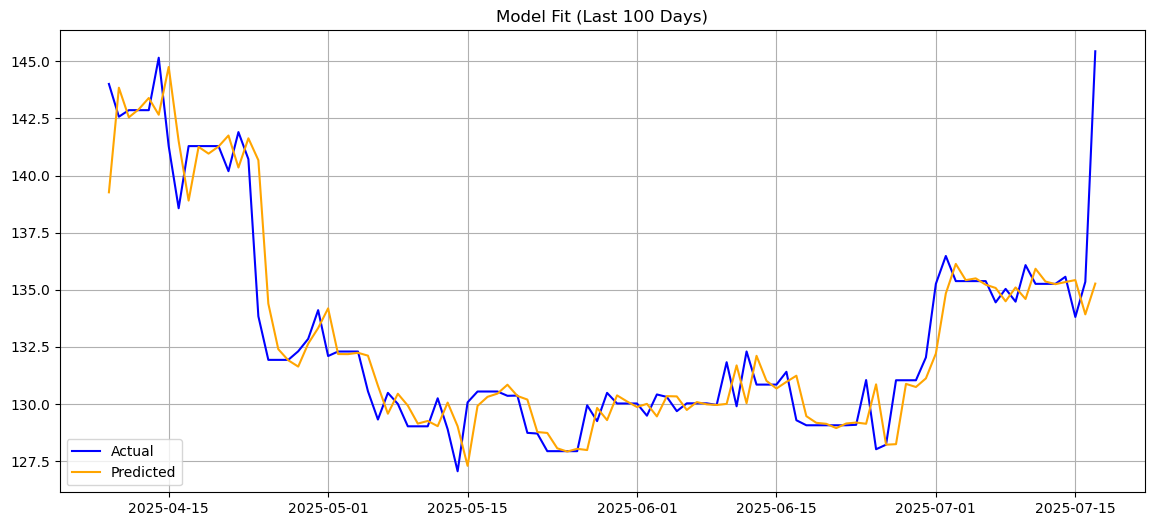

In [27]:
plt.figure(figsize=(14,6))
plt.plot(true.index, true, label="Actual", color="blue")
plt.plot(predicted.index, predicted, label="Predicted", color="orange")
plt.title("Model Fit (Last 100 Days)")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
# ARIMA Forecasting Streamlit Dashboard

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from statsmodels.tsa.arima.model import ARIMA

# --- Load or Train the Model ---
@st.cache_resource
def load_model(ts, order=(5,1,2)):
    try:
        with open("arima_model.pkl", "rb") as f:
            model_fit = pickle.load(f)
    except:
        model = ARIMA(ts, order=order)
        model_fit = model.fit()
        with open("arima_model.pkl", "wb") as f:
            pickle.dump(model_fit, f)
    return model_fit

# --- Load CSV ---
st.title("\U0001F4C8 ARIMA Time Series Forecasting Dashboard")
uploaded_file = st.file_uploader("Upload your time series CSV file (must contain 'Date' and 'Close' columns)", type=['csv'])

if uploaded_file:
    df = pd.read_csv(uploaded_file, parse_dates=["Date"])
    df.set_index("Date", inplace=True)
    df = df[df.index.notna()]
    df = df.sort_index()
    ts = df["Close"]

    st.subheader("Original Time Series")
    st.line_chart(ts[-200:])

    # Forecasting
    steps = st.slider("Select number of days to forecast", 10, 180, 60)
    model_fit = load_model(ts)
    forecast = model_fit.forecast(steps=steps)
    future_dates = pd.date_range(start=ts.index[-1], periods=steps+1, freq='D')[1:]
    forecast_df = pd.DataFrame({"Date": future_dates, "Forecasted_Close": forecast}).set_index("Date")

    # Plot forecast
    st.subheader("Forecast Plot")
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(ts[-200:], label='Historical')
    ax.plot(forecast_df, label='Forecast', color='red')
    ax.set_title("ARIMA Forecast")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend()
    st.pyplot(fig)

    # Show Data
    st.subheader("Forecasted Values")
    st.dataframe(forecast_df.head())

    # Download
    csv = forecast_df.reset_index().to_csv(index=False).encode('utf-8')
    st.download_button("Download Forecast CSV", data=csv, file_name='forecast.csv', mime='text/csv')


2025-07-25 14:05:37.447 
  command:

    streamlit run C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
